### Imports & Data Loading

The file is in HDF5 format containing four arrays:

| Key | Description |
|---|---|
| `X_jets` | Jet images of shape `(N, 125, 125, 3)` — three calorimeter channels |
| `y` | Binary labels: 0 = gluon, 1 = quark |
| `pt` | Transverse momentum of each jet (GeV) |
| `m0` | Invariant mass of each jet (GeV) |


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = h5py.File("/content/drive/MyDrive/ML4SCI/quark-gluon_data-set_n139306.hdf5", mode = "r")

In [ ]:
list(data.keys())

['X_jets', 'm0', 'pt', 'y']

In [ ]:
X_jets = np.array(data["X_jets"])

### Data Exploration

#### Average jet images

We load 20,000 samples and compute the **mean jet image** separately for quarks and gluons across each detector channel. This gives a visual sense of the typical energy deposit pattern for each class.

The three channels are:
- **HCAL** — Hadronic Calorimeter: broad, diffuse deposits from hadron showers
- **ECAL** — Electromagnetic Calorimeter: narrower deposits from electromagnetic showers
- **Tracks** — Charged particle tracks projected onto the ECAL surface


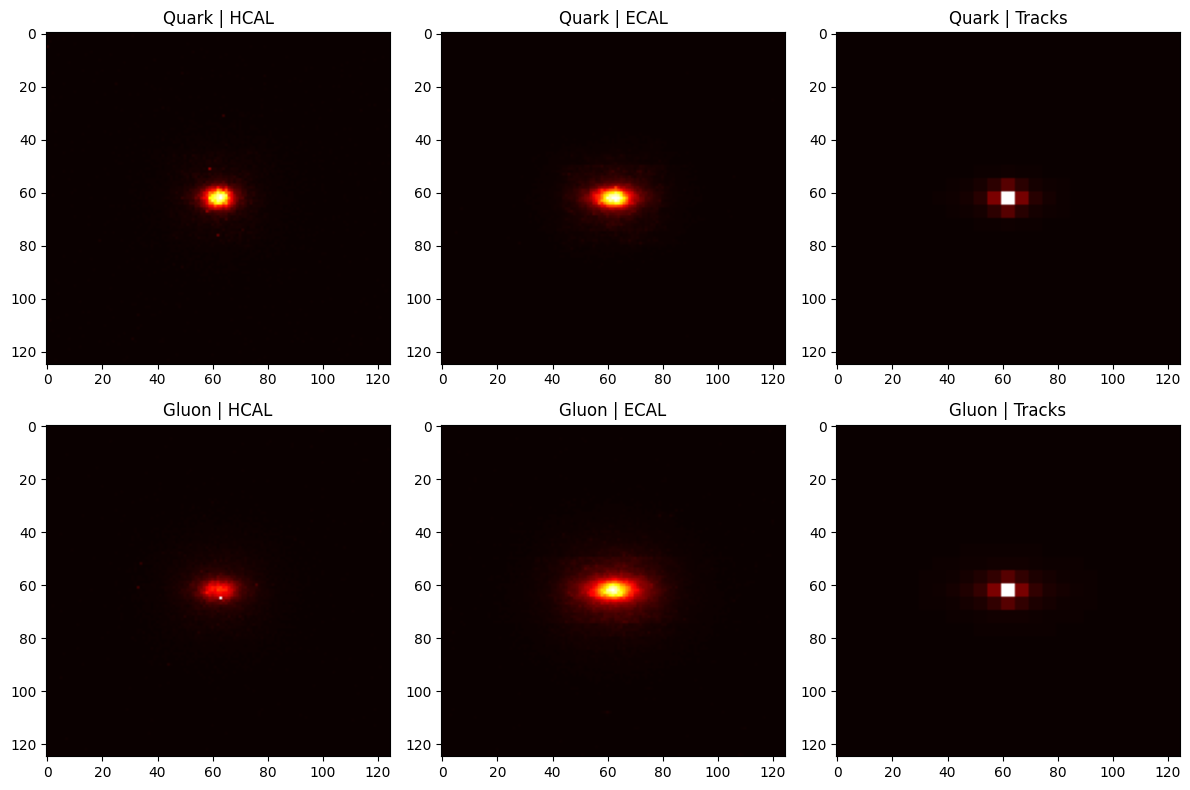

In [ ]:
# Load 20000 samples to get a general view of the data
X_jets = np.array(data["X_jets"][:30000])
m0 = np.array(data["m0"][:30000])
pt = np.array(data["pt"][:30000])
y = np.array(data["y"][:30000])

channels = ["HCAL", "ECAL", "Tracks"]

# Get the jet of quark & gluon
jet_quark = X_jets[y == 1].mean(axis = 0)
jet_gluon = X_jets[y == 0].mean(axis = 0)

# visualize Jet of quark and gluon
fig, ax = plt.subplots(2, 3, figsize= (12, 8))

for i in range(3):
  ax[0, i].imshow(jet_quark[:, :, i], cmap="hot", aspect = "auto")
  ax[0, i].set_title(f"Quark | {channels[i]}")

  ax[1, i].imshow(jet_gluon[:, :, i], cmap = "hot", aspect = "auto")
  ax[1, i].set_title(f"Gluon | {channels[i]}")
plt.tight_layout()
plt.show()


In [ ]:
quark_gluon_data_30000 = pd.DataFrame({
    'm0': m0,
    'pt': pt,
    'label': y
})

#### Class distribution

We check whether the dataset is balanced between quark and gluon jets


label
0.0    15022
1.0    14978
Name: count, dtype: int64


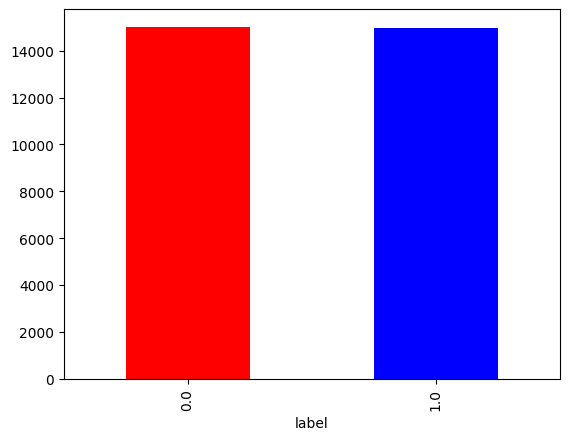

In [ ]:
# Check the class distribution
print(quark_gluon_data_30000['label'].value_counts())

# Visualization of the imbalance
quark_gluon_data_30000['label'].value_counts().plot(kind='bar', color=['red', 'blue']);

#### Dataset statistics

A full summary of the dataset including shape, class balance, and the range/mean of the kinematic variables `pt` and `m0`, plus per-channel sparsity statistics:


In [ ]:
#  getting to know the data better
print("Total samples:", len(y))
print("X_jets shape:", X_jets.shape)
print("Labels:", np.unique(y))

#  Class balance
print("\nClass Distribution:")
print(f"Quarks -> 1: {(y == 1).sum()} -> {(y==1).mean()*100:.2f}%")
print(f"Gluons -> 0: {(y == 0).sum()} -> {(y==0).mean()*100:.2f}%")

#  learning more pt and m0
print("\nTransverse Momentum (pt):")
print(f"min: {pt.min():.2f}, max: {pt.max():.2f}, mean: {pt.mean():.2f}")

print(f"\nMass (m0):")
print(f"min: {m0.min():.2f}, max: {m0.max():.2f}, mean: {m0.mean():.2f}")

#  view statistics per channel
for i, ch in enumerate(channels):
    print(f"\n{ch} channel:")
    print(f"  min: {X_jets[:,i].min():.4f}")
    print(f"  max: {X_jets[:,i].max():.4f}")
    print(f"  mean: {X_jets[:,i].mean():.4f}")
    print(f"  sparsity: {(X_jets[:,i]==0).mean()*100:.1f}% zeros")

Total samples: 30000
X_jets shape: (30000, 125, 125, 3)
Labels: [0. 1.]

Class Distribution:
Quarks -> 1: 14978 -> 49.93%
Gluons -> 0: 15022 -> 50.07%

Transverse Momentum (pt):
min: 70.63, max: 337.05, mean: 116.75

Mass (m0):
min: 3.67, max: 64.38, mean: 21.19

HCAL channel:
  min: 0.0000
  max: 0.3789
  mean: 0.0000
  sparsity: 99.2% zeros

ECAL channel:
  min: 0.0000
  max: 0.6965
  mean: 0.0000
  sparsity: 99.3% zeros

Tracks channel:
  min: 0.0000
  max: 0.5349
  mean: 0.0000
  sparsity: 99.3% zeros


#### Sparsity

A key property of jet images is their **extreme sparsity** — more than 99% of pixels in each channel are zero. This is because only a small fraction of detector cells register any energy in a given collision event. This sparsity creates a challenge for autoencoders: a model that simply outputs all zeros would achieve very low MSE loss while learning nothing useful. We address this later with a **custom weighted loss function**.


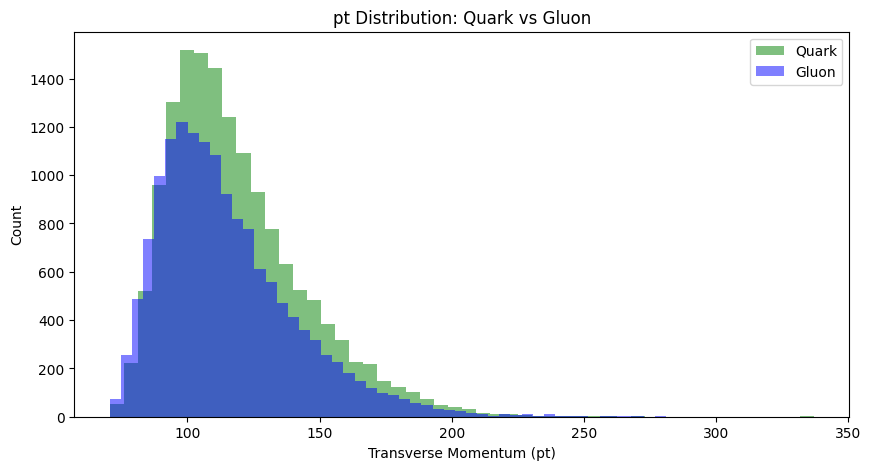

In [ ]:
import matplotlib.pyplot as plt

# Separate pt by class
quark_pt = pt[y == 1]
gluon_pt = pt[y == 0]

plt.figure(figsize=(10, 5))
plt.hist(quark_pt, bins=50, alpha=0.5, color='green', label='Quark')
plt.hist(gluon_pt, bins=50, alpha=0.5, color='blue', label='Gluon')
plt.xlabel('Transverse Momentum (pt)')
plt.ylabel('Count')
plt.title('pt Distribution: Quark vs Gluon')
plt.legend()
plt.show()

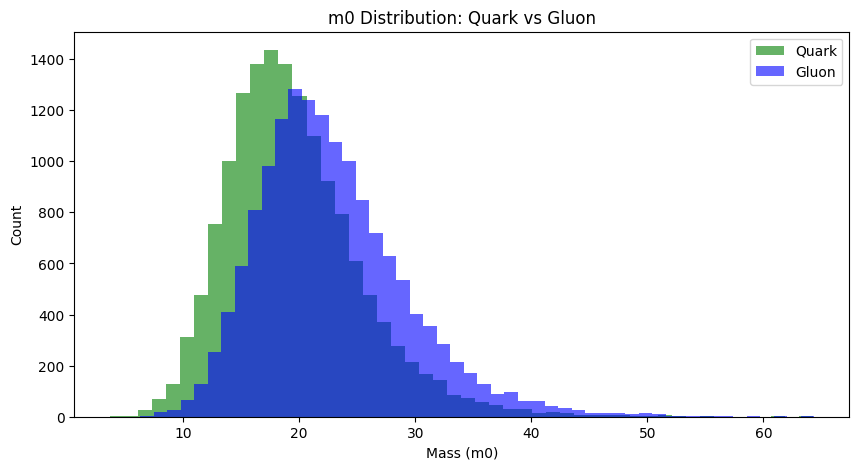

In [ ]:
quark_m0 = m0[y == 1]
gluon_m0 = m0[y == 0]

plt.figure(figsize=(10, 5))
plt.hist(quark_m0, bins=50, alpha=0.6, color='green', label='Quark')
plt.hist(gluon_m0, bins=50, alpha=0.6, color='blue', label='Gluon')
plt.xlabel('Mass (m0)')
plt.ylabel('Count')
plt.title('m0 Distribution: Quark vs Gluon')
plt.legend()
plt.show()

In [ ]:
quark_gluon_data_30000.groupby('label')[['m0', 'pt']].describe()


m0                                                       \
         count       mean       std       min        25%        50%   
label                                                                 
0.0    15022.0  22.846359  6.428003  6.307954  18.388086  21.931735   
1.0    14978.0  19.537806  5.853590  3.671971  15.502166  18.724465   

                                  pt                                    \
             75%        max    count        mean        std        min   
label                                                                    
0.0    26.342981  64.376228  15022.0  114.938141  26.039808  70.636551   
1.0    22.647404  64.266792  14978.0  118.559456  25.881304  70.632805   

                                                      
             25%         50%         75%         max  
label                                                 
0.0    96.071516  109.519138  128.195332  281.166321  
1.0    99.744278  113.087215  132.265495  337.051727

- so here the statistics shows that the m0 of the **gluon** is slightly heavier than **Quark**
- **Quark** & **Gluon** have almost identical traverse momentum
- No big difference in the traverse momentum between the **Quark** and **Gluon**

### 2. Baseline Autoencoder — `JetAutoencoder`

We will start with a **simple baseline autoencoder** to understand the difficulty of reconstructing sparse jet images.

#### Architecture

```
Input: (batch, 3, 125, 125)
    ↓
Conv2d(3 → 32, k=3, pad=1) + ReLU
MaxPool2d(5, 5)                     
    ↓
Conv2d(32 → 16, k=3, pad=1) + ReLU
MaxPool2d(5, 5)   

bottleneck
    ↓
ConvTranspose2d(16 → 32, k=5, stride=5)
    ↓
ConvTranspose2d(32 → 3, k=5, stride=5)
    ↓
Output: (batch, 3, 125, 125)
```

This simple model compresses the jet image into a small `(16, 5, 5)` bottleneck and reconstructs it back. The `Sigmoid` output constrains pixel values to `[0, 1]`. We train with standard `MSELoss` — but as we'll see, this isn't ideal for sparse data.


In [ ]:
import torch
import torch.nn as nn

# Base AutoEncoder Model
class JetAutoencoder(nn.Module):
    def __init__(self):
        super(JetAutoencoder, self).__init__()

        #  ENCODER
        # Input: (batch, 3, 125, 125)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(5, 5),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(5, 5)
        )

        # --- DECODER ---
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 32, kernel_size=5, stride=5),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=5, stride=5),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = JetAutoencoder()

In [ ]:
# Convert to Torch Tensor and Transpose (N, H, W, C) -> (N, C, H, W)
X_jets = torch.tensor(X_jets, dtype=torch.float32).permute(0, 3, 1, 2)

# Create a DataLoader for Batching
from torch.utils.data import DataLoader, TensorDataset
dataset = TensorDataset(X_jets)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training one epoch
for data in loader:
    img = data[0]
    output = model(img)
    loss = criterion(output, img)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Compare between reconstruct and the original image
model.eval()
with torch.no_grad():
    sample = X_jets[:1]
    recon = model(sample)


#### Visual comparison  original vs reconstructed

We pass one sample through the trained model and plot the original and reconstructed images side by side for all three channels:


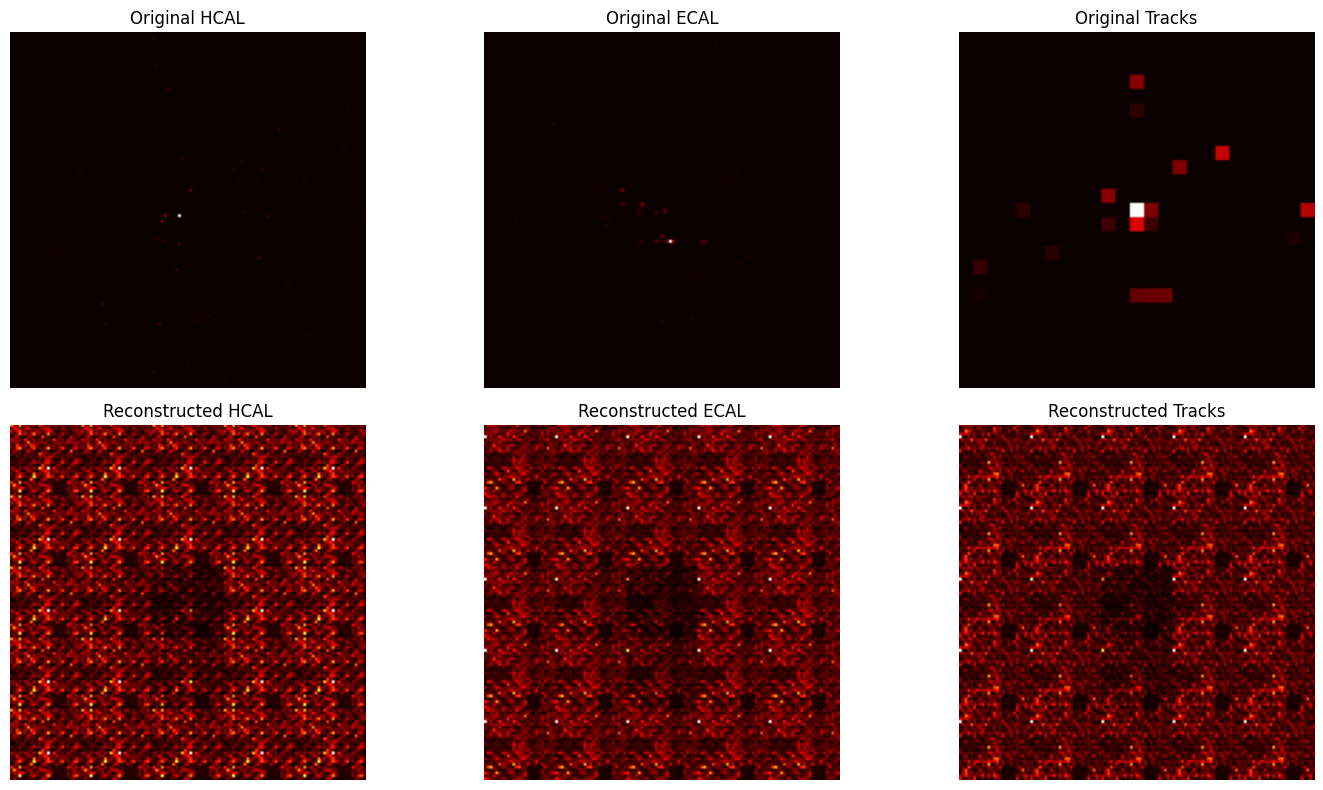

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for c in range(3):
    axes[0, c].imshow(sample[0][c].cpu().numpy(), cmap='hot')
    axes[0, c].set_title(f"Original {channels[c]}")
    axes[0, c].axis("off")

    axes[1, c].imshow(recon[0][c].cpu().numpy(), cmap='hot')
    axes[1, c].set_title(f"Reconstructed {channels[c]}")
    axes[1, c].axis("off")

plt.tight_layout()
plt.show()

#### Observation

The baseline model fails to reconstruct the sparse jet structure well. The likely reasons are:

- **Sparsity**: plain `MSELoss` penalises zero-pixel errors equally to non-zero ones — since >99% of pixels are zero, the model learns to output near-zero everywhere and still achieves low loss
- **Shallow architecture**: two conv layers with aggressive MaxPool lose too much spatial detail to reconstruct fine-grained energy deposits
- **No normalisation**: without BatchNorm, training on highly variable energy deposits is unstable


---
### 3. Improved Autoencoder — `ConvJetAutoencoder`

We redesign the autoencoder with several key improvements:

#### Architecture

```
Input: (batch, 3, 128, 128)   ← padded from 125×125
    ↓ ENCODER
Conv2d(3 → 32,   k=3, stride=2, pad=1) + BN + LeakyReLU(0.2)   → 64×64
Conv2d(32 → 64,  k=3, stride=2, pad=1) + BN + LeakyReLU(0.2)   → 32×32
Conv2d(64 → 128, k=3, stride=2, pad=1) + BN + LeakyReLU(0.2)   → 16×16
Conv2d(128 → 256,k=3, stride=2, pad=1) + BN + LeakyReLU(0.2)   → 8×8   ← bottleneck
    ↓ DECODER
ConvTranspose2d(256 → 128, k=4, stride=2, pad=1) + BN + LeakyReLU   → 16×16
ConvTranspose2d(128 → 64,  k=4, stride=2, pad=1) + BN + LeakyReLU   → 32×32
ConvTranspose2d(64 → 32,   k=4, stride=2, pad=1) + BN + LeakyReLU   → 64×64
ConvTranspose2d(32 → 16,   k=4, stride=2, pad=1) + BN + LeakyReLU   → 128×128
Conv2d(16 → 3, k=3, pad=1) + Sigmoid
    ↓
Output: (batch, 3, 128, 128)
```

**Design choices:**
| Choice | Reason |
|---|---|
| `BatchNorm2d` | Stabilises training across the wide range of energy deposit values |
| `LeakyReLU(0.2)` | Prevents dead neurons common with standard ReLU on sparse inputs |
| Strided convolutions instead of MaxPool | Learnable downsampling preserves more spatial information |
| Deeper bottleneck (256 channels at 8×8) | More expressive latent space for complex jet topologies |
| `Sigmoid` output | Constrains reconstruction to valid pixel range |


In [ ]:
import torch.nn.functional as F
import torch
from torch import nn
class ConvJetAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder Block
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Decoder Block
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 8 -> 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 32 -> 64
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),   # 64 -> 128
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

#### Data preprocessing

Before training, we apply two preprocessing steps:

1. **Log normalisation**: the pixel values have a very wide range — some energy deposits are much larger than others. We compress them into `[0, 1]` using `log1p` so the model doesn't struggle with extreme values
2. **Padding**: we pad the images from 125×125 to 128×128 because 128 is a power of 2


In [ ]:
from torch.utils.data import DataLoader, TensorDataset, random_split

X = torch.tensor(X_jets, dtype=torch.float32).permute(0, 3, 1, 2)  # (N, 3, 125, 125)

# normalizing the dynamic range of values might help in the model
X = torch.log1p(X * 50.0) / torch.log1p(torch.tensor(50.0))

# Pad 125x125 -> 128x128
X = F.pad(X, (1, 2, 1, 2))   # left, right, top, bottom

dataset = TensorDataset(X)

train_size = int(0.8 * len(dataset))
val_size   = int(0.1 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [ ]:
X.shape

torch.Size([139306, 3, 128, 128])

#### Custom weighted loss function

Since >99% of pixels are zero, a standard MSE loss would let the model cheat by outputting zeros everywhere and still get a low loss.

To fix this, we use a custom `weighted_loss` that gives **10× more importance to non-zero pixels**, so the model is forced to focus on the actual energy deposits:
```
loss = 0.7 × weighted_MSE + 0.3 × weighted_L1
```

We combine two losses:
- **MSE**
- **L1**

In [ ]:
# especial loss function to help giving the non-zero data more high values to get them appear in the model
def weighted_loss(recon, target, alpha=10.0, threshold=1e-6):
    weights = torch.ones_like(target)
    weights[target > threshold] = alpha

    mse = (weights * (recon - target) ** 2).mean()
    l1  = (weights * torch.abs(recon - target)).mean()
    return 0.7 * mse + 0.3 * l1

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvJetAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            recon = model(x)
            loss = weighted_loss(recon, x, alpha=25.0) # Corrected target to 'x'
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

num_epochs = 10
best_val = float("inf")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for (x,) in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        recon = model(x)
        loss = weighted_loss(recon, x, alpha=25.0)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss = evaluate(model, val_loader)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "autoencoder_quark_gluon.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {train_loss:.6f} | Val: {val_loss:.6f}")


Epoch [1/10] | Train: 0.008427 | Val: 0.001585
Epoch [2/10] | Train: 0.001460 | Val: 0.001367
Epoch [3/10] | Train: 0.001304 | Val: 0.001554
Epoch [4/10] | Train: 0.001206 | Val: 0.001267
Epoch [5/10] | Train: 0.001138 | Val: 0.001210
Epoch [6/10] | Train: 0.001090 | Val: 0.001454
Epoch [7/10] | Train: 0.001063 | Val: 0.001161
Epoch [8/10] | Train: 0.001050 | Val: 0.001054
Epoch [9/10] | Train: 0.001040 | Val: 0.001485
Epoch [10/10] | Train: 0.001030 | Val: 0.001458


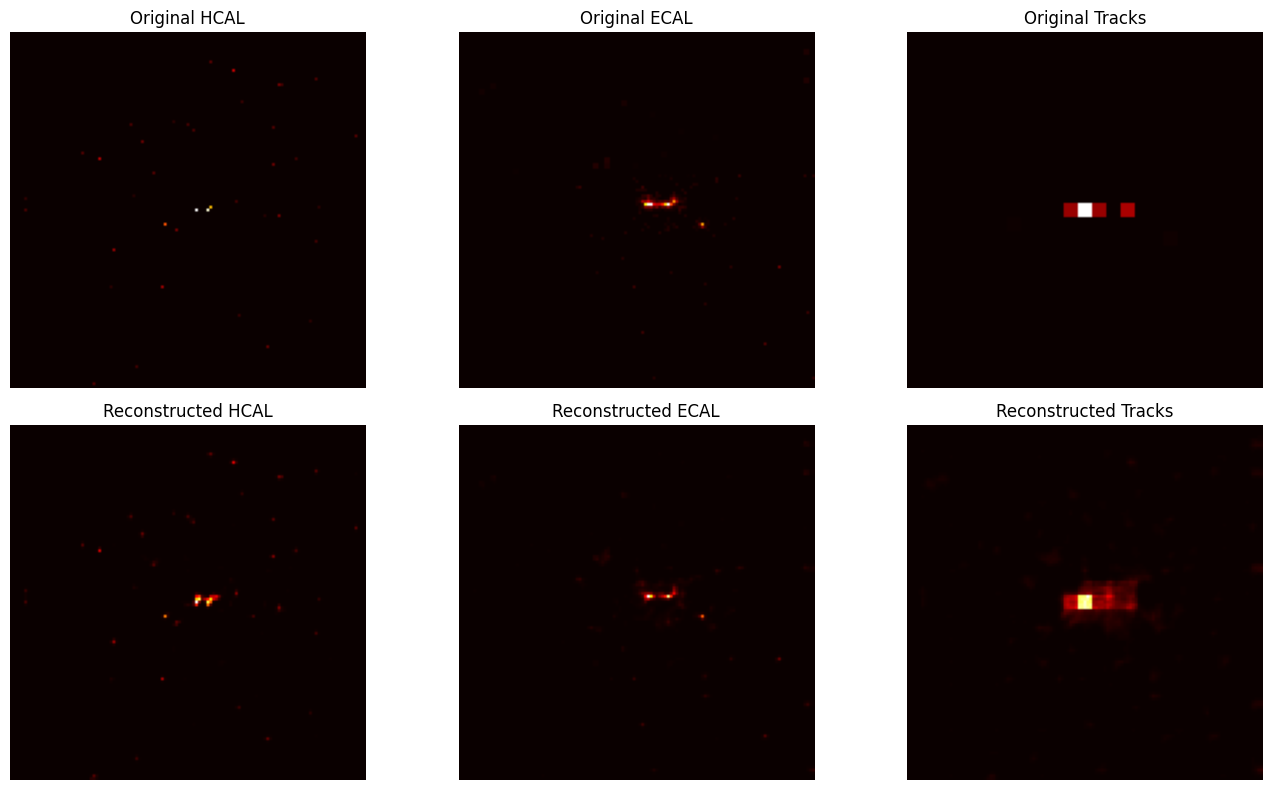

In [ ]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("autoencoder_quark_gluon.pth", map_location=device))
model.eval()

# get one batch
x_batch = next(iter(test_loader))[0].to(device)

with torch.no_grad():
    recon_batch = model(x_batch)

# remove extra padding 128x128 -> back to 125x125
x_vis = x_batch[:, :, 1:126, 1:126].cpu()
r_vis = recon_batch[:, :, 1:126, 1:126].cpu()

sample_idx = 41
channel_names = ["HCAL", "ECAL", "Tracks"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for c in range(3):
    axes[0, c].imshow(x_vis[sample_idx, c], cmap="hot")
    axes[0, c].set_title(f"Original {channel_names[c]}")
    axes[0, c].axis("off")

    axes[1, c].imshow(r_vis[sample_idx, c], cmap="hot")
    axes[1, c].set_title(f"Reconstructed {channel_names[c]}")
    axes[1, c].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install torchinfo
from torchinfo import summary

In [ ]:
summary(model = model)

Layer (type:depth-idx)                   Param #
ConvJetAutoencoder                       --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─BatchNorm2d: 2-2                  64
│    └─LeakyReLU: 2-3                    --
│    └─Conv2d: 2-4                       18,496
│    └─BatchNorm2d: 2-5                  128
│    └─LeakyReLU: 2-6                    --
│    └─Conv2d: 2-7                       73,856
│    └─BatchNorm2d: 2-8                  256
│    └─LeakyReLU: 2-9                    --
│    └─Conv2d: 2-10                      295,168
│    └─BatchNorm2d: 2-11                 512
│    └─LeakyReLU: 2-12                   --
├─Sequential: 1-2                        --
│    └─ConvTranspose2d: 2-13             524,416
│    └─BatchNorm2d: 2-14                 256
│    └─LeakyReLU: 2-15                   --
│    └─ConvTranspose2d: 2-16             131,136
│    └─BatchNorm2d: 2-17                 128
│    └─LeakyReLU: 2-18                   -

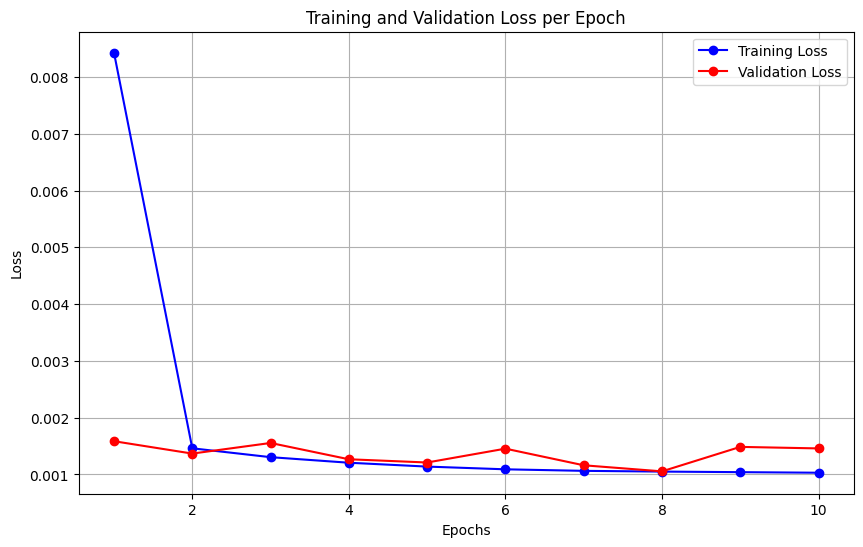

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
plt.plot(epochs, val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

---
### 4. Summary

| | Baseline (`JetAutoencoder`) | Improved (`ConvJetAutoencoder`) |
|---|---|---|
| Depth | 2 conv + 2 deconv | 4 conv + 4 deconv + 1 conv |
| Normalisation | None | BatchNorm2d at every layer |
| Activation | ReLU | LeakyReLU(0.2) |
| Loss | MSELoss | Weighted MSE + L1 (`alpha=10`) |
| Input normalisation | None | log1p scaling |
| Result | outputs near-zero everywhere | captures sparse jet structure |

